# Strawberry Pickability Classifier — MobileNetV2

**Dataset**: Pickable vs UnPickable (521 gambar, 2 kelas)  
**Strategi**: Transfer Learning 2-fase — Warmup → Fine-tuning  
**Settingan**: Sudah dioptimalkan untuk dataset kecil dengan MobileNetV2

## 1. Import & Konfigurasi

Semua hyperparameter terbaik ada di sini. Ubah sesuai kebutuhan.

In [1]:
import os, warnings
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
warnings.filterwarnings("ignore")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

print(f"TensorFlow version : {tf.__version__}")

TensorFlow version : 2.21.0


## 2. Hyperparameter Terbaik

| Parameter | Nilai | Alasan |
|---|---|---|
| `BATCH_SIZE` | 16 | Dataset kecil → gradien lebih stabil |
| `DENSE_UNITS` | 128 | Cukup untuk 2 kelas, kurangi overfit |
| `DROPOUT_RATE` | 0.4 | Regularisasi optimal dataset kecil |
| `LR_WARMUP` | 1e-3 | Standar Adam untuk head dari nol |
| `LR_FINETUNE` | 1e-5 | 100× lebih kecil, jaga pretrained weights |
| `L2_REG` | 1e-4 | Weight decay ringan |
| `FINETUNE_AT_LAYER` | 100 | Unfreeze ≈30 layer terakhir MobileNetV2 |

In [2]:
# ── PATH
DATASET_DIR       = "strawberryDataset"
SAVE_PATH         = "strawberry_mobilenetv2_model.keras"

# ── IMAGE
IMG_SIZE          = (224, 224)   # native MobileNetV2
BATCH_SIZE        = 16
SEED              = 42

# ── HEAD
DENSE_UNITS       = 128
DROPOUT_RATE      = 0.4

# ── OPTIMIZER
LR_WARMUP         = 1e-3
LR_FINETUNE       = 1e-5

# ── REGULARISASI
L2_REG            = 1e-4

# ── FINE-TUNING
FINETUNE_AT_LAYER = 100          # unfreeze dari layer ke-100 ke atas

# ── EPOCH
WARMUP_EPOCHS     = 20
FINETUNE_EPOCHS   = 30
PATIENCE          = 7

print("Konfigurasi berhasil dimuat")

Konfigurasi berhasil dimuat


## 3. Load & Split Dataset (70 / 15 / 15)

Dataset dibagi otomatis: **70% train**, **15% validasi**, **15% test**.

In [3]:
def load_data():
    # Train 70%
    train_ds = tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR,
        validation_split=0.30,
        subset="training",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="categorical",
    )
    # Val+Test 30%, lalu bagi dua
    valtest_ds = tf.keras.utils.image_dataset_from_directory(
        DATASET_DIR,
        validation_split=0.30,
        subset="validation",
        seed=SEED,
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        label_mode="categorical",
    )
    n_val   = len(valtest_ds) // 2
    val_ds  = valtest_ds.take(n_val)
    test_ds = valtest_ds.skip(n_val)

    class_names = train_ds.class_names
    print(f"  Kelas         : {class_names}")
    print(f"  Train batches : {len(train_ds)}")
    print(f"  Val batches   : {len(val_ds)}")
    print(f"  Test batches  : {len(test_ds)}")
    return train_ds, val_ds, test_ds, class_names

train_ds_raw, val_ds_raw, test_ds_raw, class_names = load_data()

Found 521 files belonging to 2 classes.
Using 365 files for training.
Found 521 files belonging to 2 classes.
Using 156 files for validation.
  Kelas         : ['Pickable', 'UnPickable']
  Train batches : 23
  Val batches   : 5
  Test batches  : 5


## 4. Augmentasi & Preprocessing Pipeline

- **Training**: augmentasi acak (flip, rotate, zoom, brightness, contrast)
- **Val/Test**: hanya preprocessing (scale ke `[-1, 1]`)

In [4]:
def make_pipeline(ds, training=False):
    preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

    augment = tf.keras.Sequential([
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.15),
        tf.keras.layers.RandomZoom(0.10),
        tf.keras.layers.RandomBrightness(0.10),
        tf.keras.layers.RandomContrast(0.10),
    ])

    def process_train(x, y):
        x = augment(x, training=True)
        return preprocess(x), y

    def process_eval(x, y):
        return preprocess(x), y

    fn = process_train if training else process_eval
    return ds.map(fn, num_parallel_calls=tf.data.AUTOTUNE).prefetch(tf.data.AUTOTUNE)

train_ds = make_pipeline(train_ds_raw, training=True)
val_ds   = make_pipeline(val_ds_raw,   training=False)
test_ds  = make_pipeline(test_ds_raw,  training=False)
print("Pipeline augmentasi siap")

Pipeline augmentasi siap


## 5. Bangun Model MobileNetV2

```
MobileNetV2 (ImageNet weights)
    ↓
GlobalAveragePooling2D
    ↓
BatchNormalization
    ↓
Dense(128, relu) + L2
    ↓
Dropout(0.4)
    ↓
Dense(2, softmax)
```

In [5]:
def build_model(unfreeze_from=None):
    """
    unfreeze_from=None → base frozen (warmup)
    unfreeze_from=N    → unfreeze layer ke-N ke atas (fine-tune)
    """
    base = tf.keras.applications.MobileNetV2(
        input_shape=(*IMG_SIZE, 3),
        include_top=False,
        weights="imagenet",
    )
    if unfreeze_from is None:
        base.trainable = False
    else:
        base.trainable = True
        for layer in base.layers[:unfreeze_from]:
            layer.trainable = False

    reg     = tf.keras.regularizers.l2(L2_REG)
    inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x       = base(inputs, training=(unfreeze_from is not None))
    x       = tf.keras.layers.GlobalAveragePooling2D()(x)
    x       = tf.keras.layers.BatchNormalization()(x)
    x       = tf.keras.layers.Dense(DENSE_UNITS, activation="relu",
                                     kernel_regularizer=reg)(x)
    x       = tf.keras.layers.Dropout(DROPOUT_RATE)(x)
    outputs = tf.keras.layers.Dense(2, activation="softmax")(x)
    return tf.keras.Model(inputs, outputs), base


def get_callbacks(phase="warmup"):
    save = SAVE_PATH if phase == "finetune" else "warmup_checkpoint_mobilenetv2_model.keras"
    return [
        tf.keras.callbacks.ModelCheckpoint(
            save, monitor="val_accuracy", save_best_only=True, verbose=1),
        tf.keras.callbacks.EarlyStopping(
            monitor="val_accuracy", patience=PATIENCE,
            restore_best_weights=True, verbose=1),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor="val_loss", factor=0.5, patience=3, min_lr=1e-7, verbose=1),
    ]


model, base = build_model(unfreeze_from=None)
trainable = sum(np.prod(w.shape) for w in model.trainable_weights)
total     = sum(np.prod(w.shape) for w in model.weights)
print(f"Total parameter    : {total:,}")
print(f"Trainable parameter: {trainable:,}  (head saja)")
model.summary()

Total parameter    : 2,427,330
Trainable parameter: 166,786  (head saja)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,427,330 (9.26 MB)

 Trainable params: 166,786 (651.51 KB)

 Non-trainable params: 2,260,544 (8.62 MB)

## 6. Phase 1 — Warmup Training

Base MobileNetV2 **di-freeze** sepenuhnya.  
Hanya classification head yang dilatih dari nol dengan `LR = 1e-3`.

In [6]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_WARMUP),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print(f"Warmup training — max {WARMUP_EPOCHS} epoch, LR={LR_WARMUP}\n")
history_warmup = model.fit(
    train_ds,
    epochs=WARMUP_EPOCHS,
    validation_data=val_ds,
    callbacks=get_callbacks("warmup"),
)

best_warmup = max(history_warmup.history["val_accuracy"])
print(f"\nBest val_accuracy (warmup): {best_warmup:.4f}")

Warmup training — max 20 epoch, LR=0.001

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 340ms/step - accuracy: 0.7979 - loss: 0.7223
Epoch 1: val_accuracy improved from None to 0.97500, saving model to warmup_checkpoint_mobilenetv2_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 17s 499ms/step - accuracy: 0.9096 - loss: 0.3416 - val_accuracy: 0.9750 - val_loss: 0.0576 - learning_rate: 0.0010
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 301ms/step - accuracy: 0.9668 - loss: 0.0996
Epoch 2: val_accuracy improved from 0.97500 to 0.98750, saving model to warmup_checkpoint_mobilenetv2_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 389ms/step - accuracy: 0.9671 - loss: 0.1412 - val_accuracy: 0.9875 - val_loss: 0.0535 - learning_rate: 0.0010
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 328ms/step - accuracy: 0.9857 - loss: 0.0848
Epoch 3: val_accuracy did not improve from 0.98750
23/23 ━━━━━━━━━━━━━━━━━━━━ 10s 404ms/step - accuracy: 0.9781 - loss: 0.1230 - val_accuracy: 0.9750 - val_loss: 0.0604 - learning_rate: 0.001

### Plot History Warmup

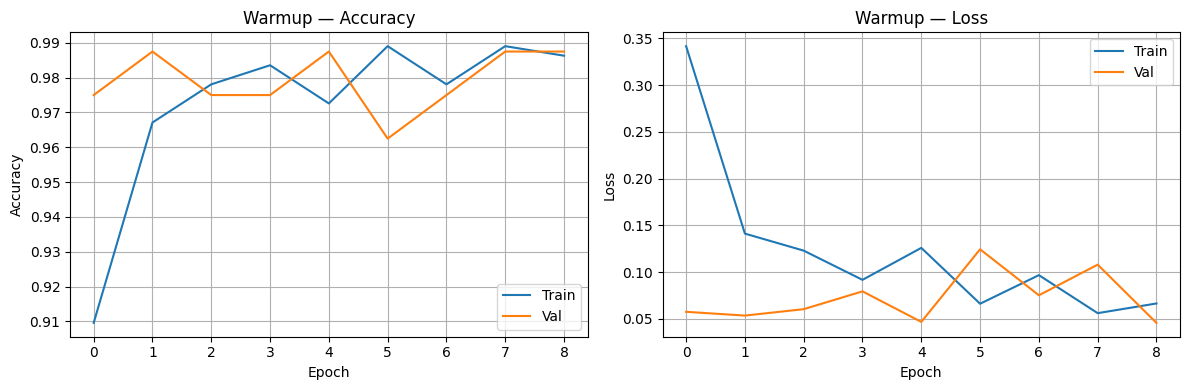

In [7]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_warmup.history["accuracy"],     label="Train")
ax1.plot(history_warmup.history["val_accuracy"], label="Val")
ax1.set_title("Warmup — Accuracy")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(True)

ax2.plot(history_warmup.history["loss"],     label="Train")
ax2.plot(history_warmup.history["val_loss"], label="Val")
ax2.set_title("Warmup — Loss")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## 7. Phase 2 — Fine-Tuning

Unfreeze **layer ke-100 ke atas** (≈30 layer terakhir MobileNetV2).  
Learning rate dikecilkan 100× menjadi `1e-5` agar pretrained weights tidak rusak.

In [8]:
base.trainable = True
for layer in base.layers[:FINETUNE_AT_LAYER]:
    layer.trainable = False

trainable_ft = sum(np.prod(w.shape) for w in model.trainable_weights)
print(f"Trainable parameter setelah unfreeze: {trainable_ft:,}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(LR_FINETUNE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

print(f"\nFine-tune training — max {FINETUNE_EPOCHS} epoch, LR={LR_FINETUNE}\n")
history_ft = model.fit(
    train_ds,
    epochs=FINETUNE_EPOCHS,
    validation_data=val_ds,
    callbacks=get_callbacks("finetune"),
)

best_ft = max(history_ft.history["val_accuracy"])
print(f"\nBest val_accuracy (fine-tune): {best_ft:.4f}")

Trainable parameter setelah unfreeze: 2,028,226

Fine-tune training — max 30 epoch, LR=1e-05

Epoch 1/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.8657 - loss: 0.3467
Epoch 1: val_accuracy improved from None to 1.00000, saving model to strawberry_mobilenetv2_model.keras
23/23 ━━━━━━━━━━━━━━━━━━━━ 22s 547ms/step - accuracy: 0.8767 - loss: 0.3420 - val_accuracy: 1.0000 - val_loss: 0.0406 - learning_rate: 1.0000e-05
Epoch 2/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step - accuracy: 0.9174 - loss: 0.2335
Epoch 2: val_accuracy did not improve from 1.00000
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 479ms/step - accuracy: 0.9123 - loss: 0.2665 - val_accuracy: 0.9875 - val_loss: 0.0530 - learning_rate: 1.0000e-05
Epoch 3/30
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 417ms/step - accuracy: 0.9200 - loss: 0.2914
Epoch 3: val_accuracy did not improve from 1.00000
23/23 ━━━━━━━━━━━━━━━━━━━━ 12s 488ms/step - accuracy: 0.9342 - loss: 0.2389 - val_accuracy: 1.0000 - val_loss: 0.0449 - learning_rate: 1.0000e-05
Epoc

### Plot History Fine-Tuning

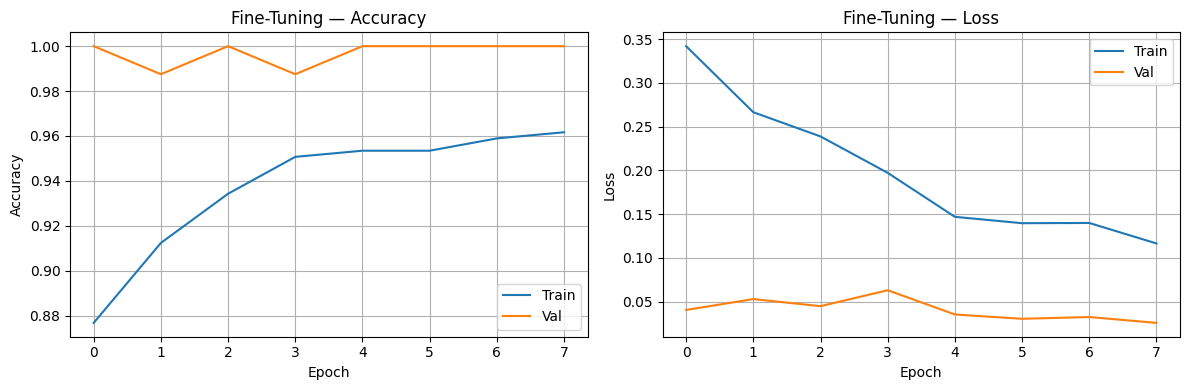

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history_ft.history["accuracy"],     label="Train")
ax1.plot(history_ft.history["val_accuracy"], label="Val")
ax1.set_title("Fine-Tuning — Accuracy")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Accuracy")
ax1.legend(); ax1.grid(True)

ax2.plot(history_ft.history["loss"],     label="Train")
ax2.plot(history_ft.history["val_loss"], label="Val")
ax2.set_title("Fine-Tuning — Loss")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Loss")
ax2.legend(); ax2.grid(True)

plt.tight_layout()
plt.show()

## 8. Evaluasi Model Terbaik pada Test Set

Memuat checkpoint model terbaik, lalu evaluasi akurasi, precision, recall, dan F1.

In [10]:
best_model = tf.keras.models.load_model(SAVE_PATH)

loss, acc = best_model.evaluate(test_ds, verbose=0)
print(f"Test Loss     : {loss:.4f}")
print(f"Test Accuracy : {acc:.4f}  ({acc*100:.2f}%)")

# Per-kelas metrics
y_true, y_pred = [], []
for images, labels in test_ds:
    preds = best_model.predict(images, verbose=0)
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print(f"\n{'Kelas':<15} {'Precision':>10} {'Recall':>10} {'F1':>10} {'Support':>10}")
print("-" * 55)
for i, cls in enumerate(class_names):
    tp = np.sum((y_pred == i) & (y_true == i))
    fp = np.sum((y_pred == i) & (y_true != i))
    fn = np.sum((y_pred != i) & (y_true == i))
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    f1        = 2 * precision * recall / (precision + recall + 1e-8)
    support   = np.sum(y_true == i)
    print(f"{cls:<15} {precision:>10.4f} {recall:>10.4f} {f1:>10.4f} {support:>10}")

macro_f1 = np.mean([
    2 * (np.sum((y_pred==i)&(y_true==i)) / (np.sum(y_pred==i)+1e-8)) *
        (np.sum((y_pred==i)&(y_true==i)) / (np.sum(y_true==i)+1e-8)) /
        ((np.sum((y_pred==i)&(y_true==i)) / (np.sum(y_pred==i)+1e-8)) +
         (np.sum((y_pred==i)&(y_true==i)) / (np.sum(y_true==i)+1e-8)) + 1e-8)
    for i in range(len(class_names))
])
print(f"\nMacro F1 Score : {macro_f1:.4f}")

Test Loss     : 0.0621
Test Accuracy : 0.9737  (97.37%)

Kelas            Precision     Recall         F1    Support
-------------------------------------------------------
Pickable            1.0000     0.9750     0.9873         40
UnPickable          0.9730     1.0000     0.9863         36

Macro F1 Score : 0.9868


### Confusion Matrix

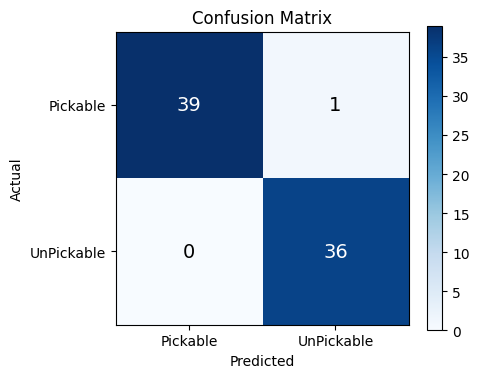

In [11]:
fig, ax = plt.subplots(figsize=(5, 4))
cm = np.zeros((2, 2), dtype=int)
for t, p in zip(y_true, y_pred):
    cm[t][p] += 1

im = ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_yticks([0, 1])
ax.set_xticklabels(class_names); ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center",
                color="white" if cm[i, j] > cm.max()/2 else "black", fontsize=14)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

## 9. Prediksi Gambar Baru

Ganti `IMAGE_PATH` dengan path gambar stroberi yang ingin diprediksi.

In [12]:
def predict_image(image_path, model, class_names):
    img = tf.keras.utils.load_img(image_path, target_size=IMG_SIZE)
    arr = tf.keras.utils.img_to_array(img)
    arr = tf.keras.applications.mobilenet_v2.preprocess_input(arr)
    arr = np.expand_dims(arr, axis=0)

    probs = model.predict(arr, verbose=0)[0]
    idx   = np.argmax(probs)

    plt.figure(figsize=(4, 4))
    plt.imshow(tf.keras.utils.load_img(image_path, target_size=IMG_SIZE))
    plt.axis("off")
    plt.title(f"Prediksi: {class_names[idx]}\n"
              f"Confidence: {probs[idx]*100:.1f}%", fontsize=12)
    plt.tight_layout()
    plt.show()
    return class_names[idx], probs

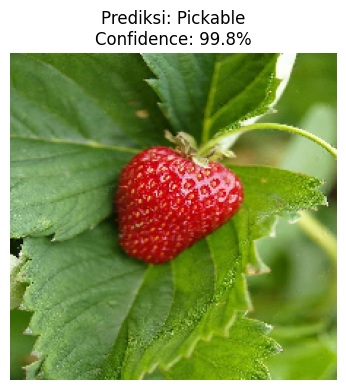

Hasil: Pickable (Pickable: 99.8% | UnPickable: 0.2%)


In [13]:
loaded_model = tf.keras.models.load_model("strawberry_mobilenetv2_model.keras")
IMAGE_PATH = "testingDataset/matang.webp"
label, probs = predict_image(IMAGE_PATH, loaded_model, class_names)
print(f"Hasil: {label} (Pickable: {probs[0]*100:.1f}% | UnPickable: {probs[1]*100:.1f}%)")

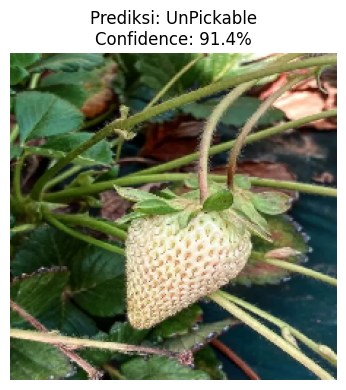

Hasil: Pickable (Pickable: 8.6% | UnPickable: 91.4%)


In [14]:
IMAGE_PATH = "testingDataset/mentah.webp"
label2, probs2 = predict_image(IMAGE_PATH, loaded_model, class_names)
print(f"Hasil: {label} (Pickable: {probs2[0]*100:.1f}% | UnPickable: {probs2[1]*100:.1f}%)")